In [1]:
import pandas as pd
from sklearn.linear_model import LinearRegression
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

AADT = pd.read_csv(r"..\Uncleaned dataset\AADT 2015-2024.csv")

print(AADT.describe())
print(AADT.info())

              year           puj           uv           pub
count   202.000000    201.000000    160.00000    201.000000
mean   2019.440594   5889.119403   2542.46875   1397.626866
std       2.926791   5563.558205   3472.26722   2299.698397
min    2013.000000      0.000000      2.00000      1.000000
25%    2017.000000    763.000000     64.00000    213.000000
50%    2019.000000   4533.000000    665.50000    614.000000
75%    2022.000000   9815.000000   3772.75000   1452.000000
max    2024.000000  27533.000000  13236.00000  14384.000000
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 202 entries, 0 to 201
Data columns (total 13 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   year       202 non-null    int64  
 1   road_type  202 non-null    object 
 2   road_name  202 non-null    object 
 3   car        201 non-null    object 
 4   puj        201 non-null    float64
 5   uv         160 non-null    float64
 6   taxi       160 non-null    obj

In [2]:
def unique(dataset):
    print(dataset.nunique())
    print(dataset.unique())
AADT.head()

,year,road_type,road_name,car,puj,uv,taxi,pub,truck,trailer,mc,tricycle,total
0,2013,R-10,DEL PAN,31887,24.0,NaN,NaN,24.0,4455,6566,9956,627,53539
1,2014,R-10,DEL PAN,21326,1902.0,NaN,NaN,48.0,4974,3856,11737,1822,45665
2,2015,C-1,RECTO,30216,15736.0,NaN,NaN,643.0,769,16,19220,3906,70506
3,2015,C-2,MENDOZA,63469,72.0,NaN,NaN,193.0,4007,508,22611,984,91842
4,2015,C-2,PRES. QUIRINO,76073,5019.0,NaN,NaN,173.0,6421,3070,28541,527,119824


In [3]:
AADT = AADT.rename(columns={'road_type':'road_t','road_name':'road_n'})
unique(AADT['road_t'])
unique(AADT['year'])
unique(AADT['road_n'])
print(AADT['road_n'].value_counts())

31
['R-10' 'C-1' 'C-2' 'C-3' 'C-4' 'C-5' 'R-1' 'R-2' 'R-3' 'R-4' 'R-5' 'R-6'
 'R-7' 'R-8' 'R-9' 'R-11' 'C1' 'C2' 'C3' 'C4' 'C5' 'R1' 'R2' 'R3' 'R4'
 'R5' 'R6' 'R7' 'R8' 'R9' 'R10']
12
[2013 2014 2015 2016 2017 2018 2019 2020 2021 2022 2023 2024]
40
['DEL PAN' 'RECTO' 'MENDOZA' 'PRES. QUIRINO' 'ARANETA AVE.'
 'EDSA (BUENDIA AVE.)' 'KATIPUNAN / C.P. GARCIA' 'ROXAS BLVD.' 'TAFT AVE.'
 'SSH' 'SHAW BLVD.' 'ORTIGAS AVE.' 'MAGSAYSAY BLVD.' 'AURORA BLVD.'
 'QUEZON AVE.' 'COMMONWEALTH AVE.' 'A. BONIFACIO' 'RIZAL AVE.'
 'MARCOS HWY.' 'MCARTHUR HWY.' 'RECTOR' 'EDSA' 'PRES. QUIRINO AVE.'
 'MARCOS HIGHWAY' 'MCARTHUR HIGHWAY'
 'C.P. GARCIA / KATIPUNAN AVE. / TANDANG SORA' 'RACTO AVENUE'
 'ARANETA AVENUE' 'C.P. GARCIA / KATIPUNAN AVENUE / TANDANG SORA'
 'ROXAS BOULEVARD' 'TAFT AVENUE' 'SHAW BOULEVARD' 'ORTIGAS AVENUE'
 'MAGSAYSAY BOULEVARD' 'AURORA BOULEVARD' 'QUEZON AVENUE'
 'COMMONWEALTH AVENUE' 'RIZAL AVENUE' 'RECTO AVENUE'
 'PRES. QUIRINO AVENUE']
road_n
DEL PAN                                   

In [4]:
AADT['road_t'] = AADT['road_t'].str.replace('-','')
unique(AADT['road_t'])

recto_p = r'\bR[EA]CT[OA]\w*.*'
quirino_p = r'.*PRES\.?\s*QUIRINO.*'
areneta_p = r'ARANETA AVE.*'
edsa_p = r'EDSA .*'
AADT["road_n"] = AADT["road_n"].str.replace(recto_p, 'RECTO', regex=True)
AADT["road_n"] = AADT["road_n"].str.replace(quirino_p, 'QUIRINO AVENUE', regex=True)
AADT["road_n"] = AADT["road_n"].str.replace(areneta_p, 'ARANETA AVENUE', regex=True)
AADT["road_n"] = AADT["road_n"].str.replace(edsa_p, 'EDSA', regex=True)

replace_rnames = {
    'C5':['C.P. GARCIA / KATIPUNAN AVE. / TANDANG SORA', 'C.P. GARCIA / KATIPUNAN AVENUE / TANDANG SORA','KATIPUNAN / C.P. GARCIA'],
    'ROXAS BOULEVARD': ['ROXAS BLVD.'],
    'TAFT AVENUE': ['TAFT AVE.'],
    'SHAW BOULEVARD':['SHAW BLVD.'],
    'ORTIGAS AVENUE': ['ORTIGAS AVE.'],
    'MAGSAYSAY BOULEVARD':['MAGSAYSAY BLVD.'],
    'AURORA BOULEVARD':['AURORA BLVD.'],
    'QUEZON AVENUE':['QUEZON AVE.'],
    'COMMONWEALTH AVENUE':['COMMONWEALTH AVE.'],
    'RIZAL AVENUE':['RIZAL AVE.'],
    'MARCOS HIGHWAY':['MARCOS HWY.'],
    'MCARTHUR HIGHWAY':['MCARTHUR HWY.']
}
for correct_name, variants in replace_rnames.items():
    for variant in variants:
        AADT["road_n"] = AADT["road_n"].replace(variant, correct_name)

unique(AADT['road_n'])
print(AADT['road_n'].value_counts())

16
['R10' 'C1' 'C2' 'C3' 'C4' 'C5' 'R1' 'R2' 'R3' 'R4' 'R5' 'R6' 'R7' 'R8'
 'R9' 'R11']
20
['DEL PAN' 'RECTO' 'MENDOZA' 'QUIRINO AVENUE' 'ARANETA AVENUE' 'EDSA' 'C5'
 'ROXAS BOULEVARD' 'TAFT AVENUE' 'SSH' 'SHAW BOULEVARD' 'ORTIGAS AVENUE'
 'MAGSAYSAY BOULEVARD' 'AURORA BOULEVARD' 'QUEZON AVENUE'
 'COMMONWEALTH AVENUE' 'A. BONIFACIO' 'RIZAL AVENUE' 'MARCOS HIGHWAY'
 'MCARTHUR HIGHWAY']
road_n
DEL PAN                12
RECTO                  10
MARCOS HIGHWAY         10
RIZAL AVENUE           10
A. BONIFACIO           10
COMMONWEALTH AVENUE    10
QUEZON AVENUE          10
AURORA BOULEVARD       10
MAGSAYSAY BOULEVARD    10
ORTIGAS AVENUE         10
SHAW BOULEVARD         10
SSH                    10
TAFT AVENUE            10
ROXAS BOULEVARD        10
C5                     10
EDSA                   10
ARANETA AVENUE         10
QUIRINO AVENUE         10
MENDOZA                10
MCARTHUR HIGHWAY       10
Name: count, dtype: int64


In [5]:
pred_AADT = AADT[(AADT['year'] != 2015) & (AADT['road_n'] == 'DEL PAN')]
missing_year = 2015

X = pred_AADT['year'].values.reshape(-1, 1)

vehicle_cols = ['car', 'puj', 'pub', 'truck', 'trailer', 'mc', 'tricycle']

model = LinearRegression()
counter = 0
for col in vehicle_cols:
    y = pred_AADT[col].values
    
    model.fit(X, y)
    
    pred = model.predict([[missing_year]])[0]
    
    idx = AADT[(AADT['year'] == 2015) & (AADT['road_n'] == 'DEL PAN')].index[0]
    
    AADT.loc[idx, col] = int(pred)

    print(f"{vehicle_cols[counter]} predicted: {pred}")
    counter += 1

idx = AADT[(AADT['year'] == 2015) & (AADT['road_n'] == 'DEL PAN')].index[0]
AADT.loc[idx, 'total'] = AADT.loc[idx, vehicle_cols].sum()
AADT_copy = AADT
AADT.head(22)
AADT.isnull().sum()

car predicted: 30483.22720897617
puj predicted: 1421.4460028050235
pub predicted: 60.72370266479629
truck predicted: 5007.096774193546
trailer predicted: 5229.835904628388
mc predicted: 16699.4614305757
tricycle predicted: 1727.6563814866822


year         0
road_t       0
road_n       0
car          0
puj          0
uv          42
taxi        42
pub          0
truck        0
trailer      0
mc           0
tricycle     0
total        0
dtype: int64

In [6]:
AADT = AADT.drop([0,1])
AADT['uv'] = AADT['uv'].fillna(0)
AADT['taxi'] = AADT['taxi'].fillna(0)
AADT.head()

,year,road_t,road_n,car,puj,uv,taxi,pub,truck,trailer,mc,tricycle,total
2,2015,C1,RECTO,30216,15736.0,0.0,0,643.0,769,16,19220,3906,70506
3,2015,C2,MENDOZA,63469,72.0,0.0,0,193.0,4007,508,22611,984,91842
4,2015,C2,QUIRINO AVENUE,76073,5019.0,0.0,0,173.0,6421,3070,28541,527,119824
5,2015,C3,ARANETA AVENUE,54670,2228.0,0.0,0,21.0,4393,528,25111,2769,89720
6,2015,C4,EDSA,284436,2944.0,0.0,0,14384.0,5451,8,60432,20,367675


In [7]:
AADT['year'] = pd.to_datetime(AADT['year'], format='%Y')

col_str = ['road_t','road_n']
col_int = ['car','puj','uv','taxi','pub','truck','trailer','mc','tricycle','total']
def col_type(col_n, type_val):
    for i in col_n:
        if type_val == 'int':
            AADT[i] = AADT[i].astype(str).str.replace(',', '')
            AADT[i] = AADT[i].astype(str).str.replace('.', '')
        AADT[i] = AADT[i].astype(type_val)
        
col_type(col_str, 'str')
col_type(col_int, 'int')
AADT.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 2 to 201
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   year      200 non-null    datetime64[ns]
 1   road_t    200 non-null    object        
 2   road_n    200 non-null    object        
 3   car       200 non-null    int32         
 4   puj       200 non-null    int32         
 5   uv        200 non-null    int32         
 6   taxi      200 non-null    int32         
 7   pub       200 non-null    int32         
 8   truck     200 non-null    int32         
 9   trailer   200 non-null    int32         
 10  mc        200 non-null    int32         
 11  tricycle  200 non-null    int32         
 12  total     200 non-null    int32         
dtypes: datetime64[ns](1), int32(10), object(2)
memory usage: 12.6+ KB


array([[<Axes: title={'center': 'year'}>,
        <Axes: title={'center': 'car'}>, <Axes: title={'center': 'puj'}>],
       [<Axes: title={'center': 'uv'}>, <Axes: title={'center': 'taxi'}>,
        <Axes: title={'center': 'pub'}>],
       [<Axes: title={'center': 'truck'}>,
        <Axes: title={'center': 'trailer'}>,
        <Axes: title={'center': 'mc'}>],
       [<Axes: title={'center': 'tricycle'}>,
        <Axes: title={'center': 'total'}>, <Axes: >]], dtype=object)

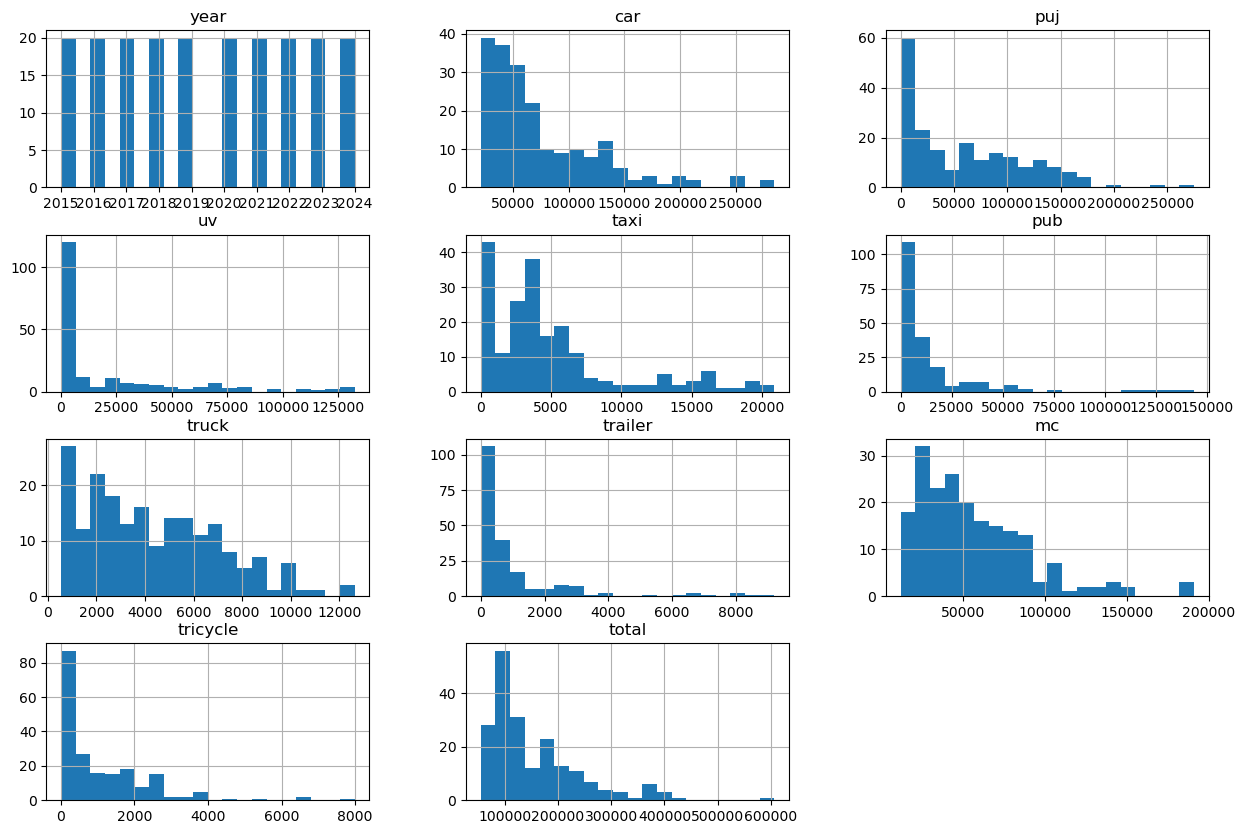

In [8]:
AADT.hist(figsize=(15, 10), bins=20)

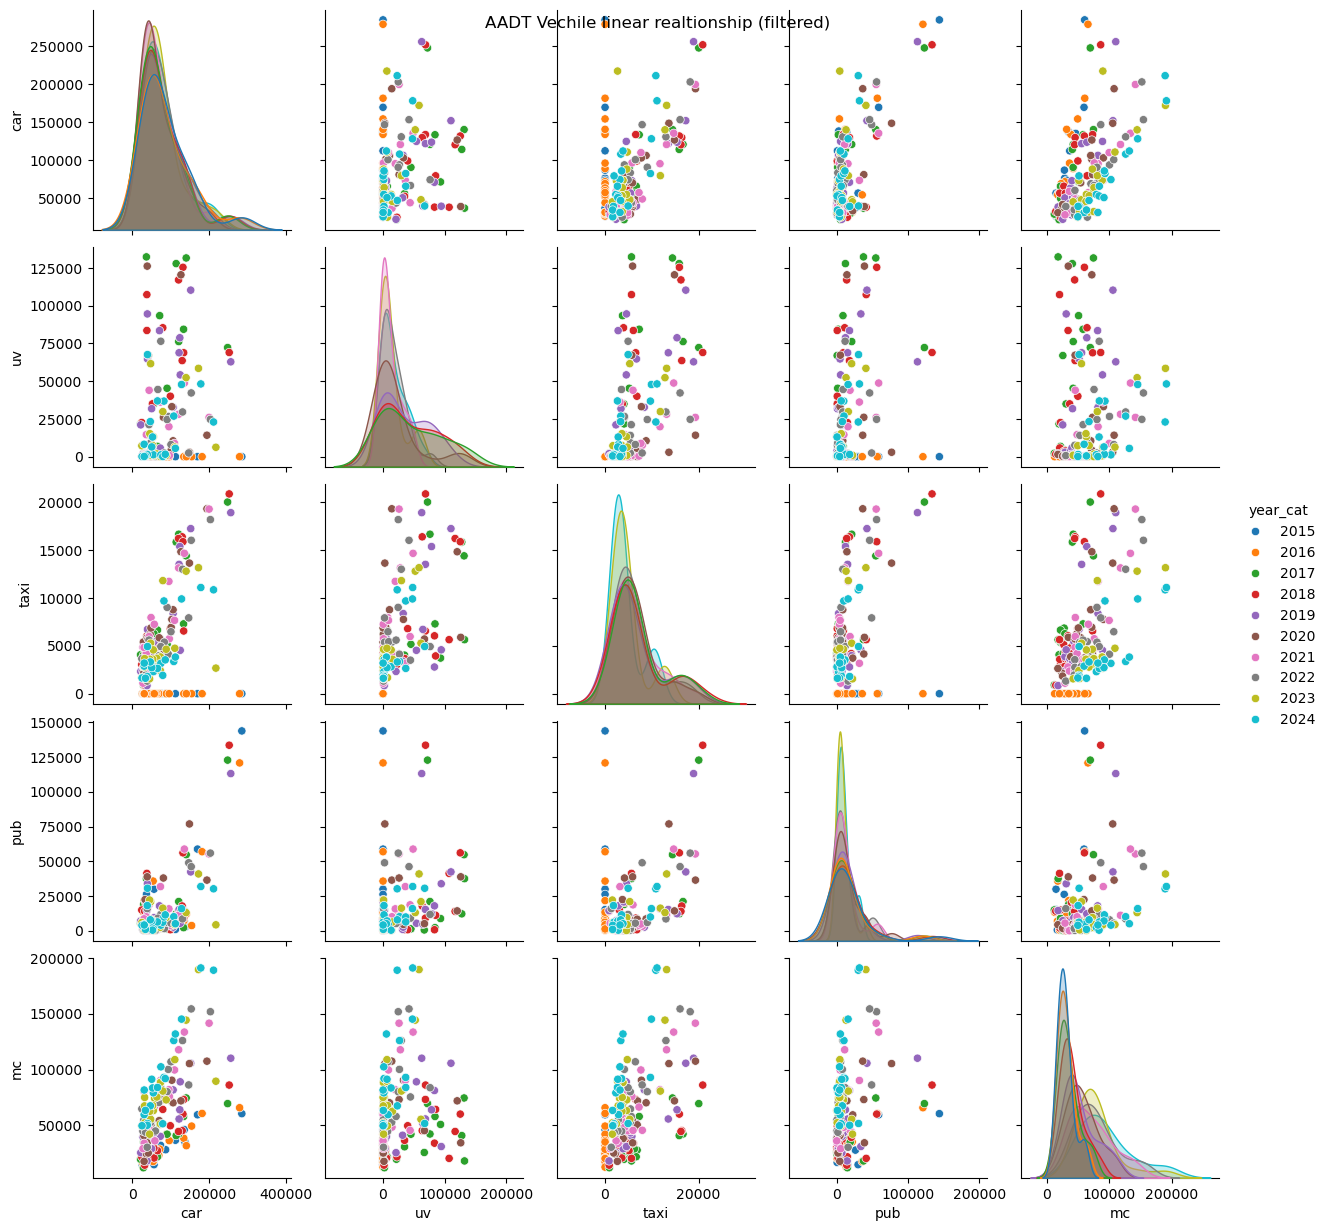

In [9]:
AADT['year_cat'] = AADT['year'].dt.year
sns.pairplot(AADT[['car', 'uv', 'taxi', 'pub', 'mc'] + ['year_cat']],
             hue='year_cat', 
             diag_kind='kde', 
             palette='tab10')
plt.suptitle('AADT Vechile linear realtionship (filtered)')
plt.savefig('AADT Vechile linear realtionship.png', dpi=300, bbox_inches='tight')
plt.show()

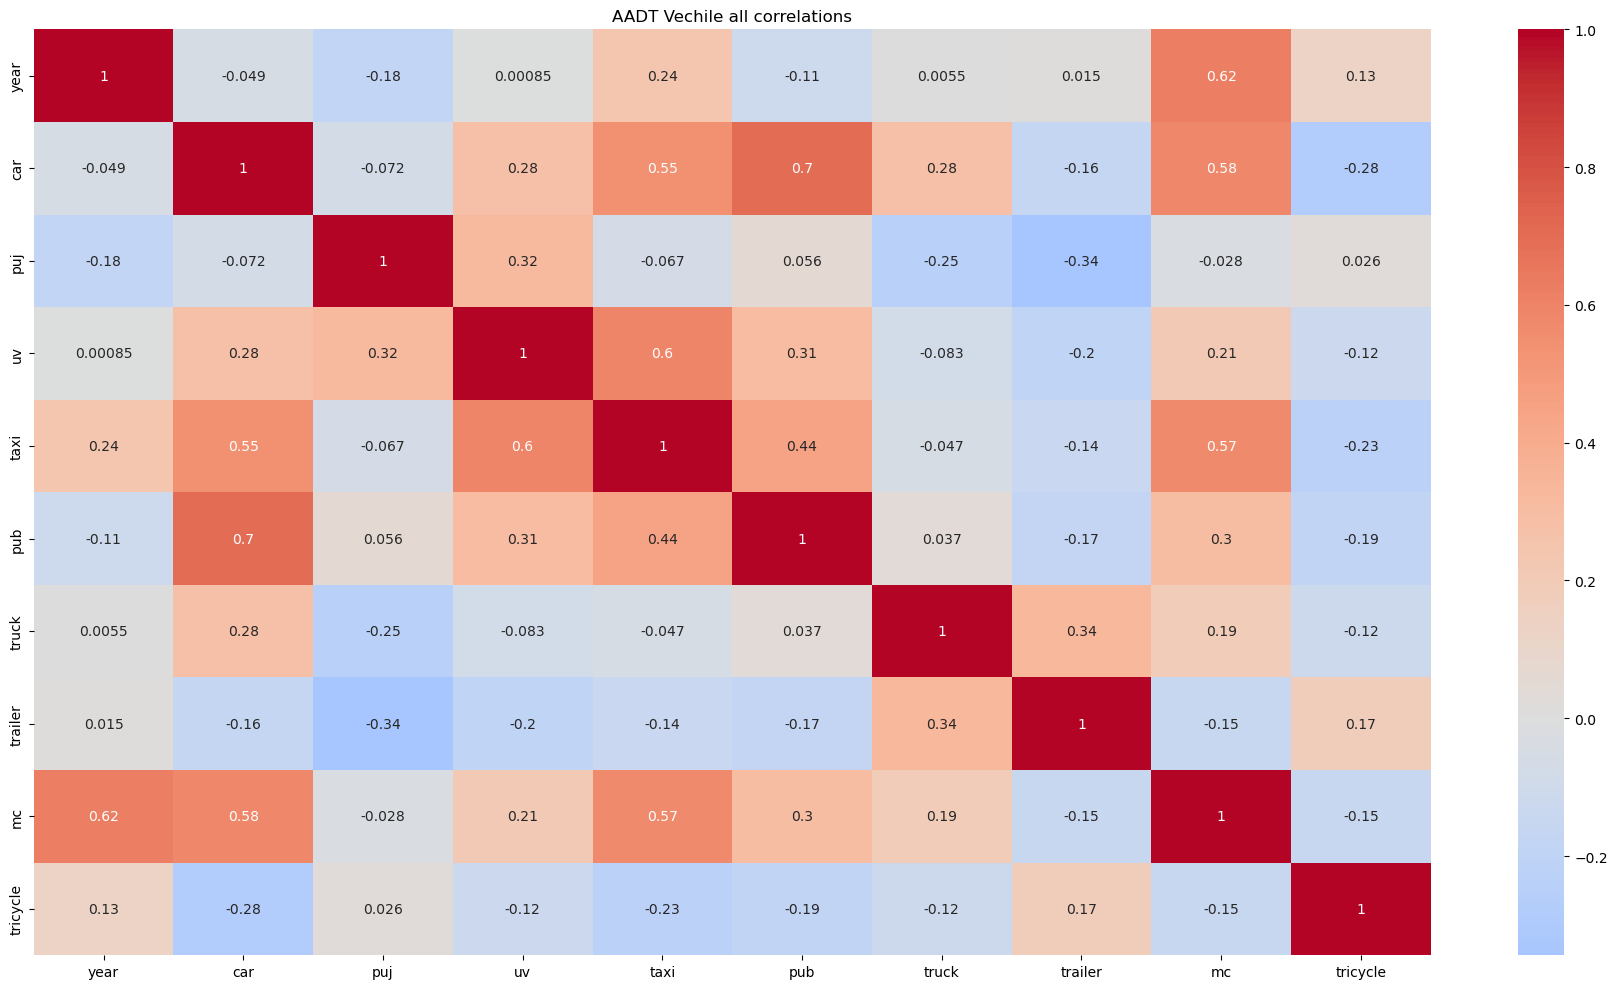

In [10]:
plt.figure(figsize=(18, 10))
sns.heatmap(AADT[['year','car','puj','uv','taxi','pub','truck','trailer','mc','tricycle']].corr(),
            annot=True, 
            cmap='coolwarm', 
            center=0)
plt.title('AADT Vechile all correlations')
plt.tight_layout()
plt.savefig('AADT Vechile all correlations.png', dpi=300, bbox_inches='tight')
plt.show()

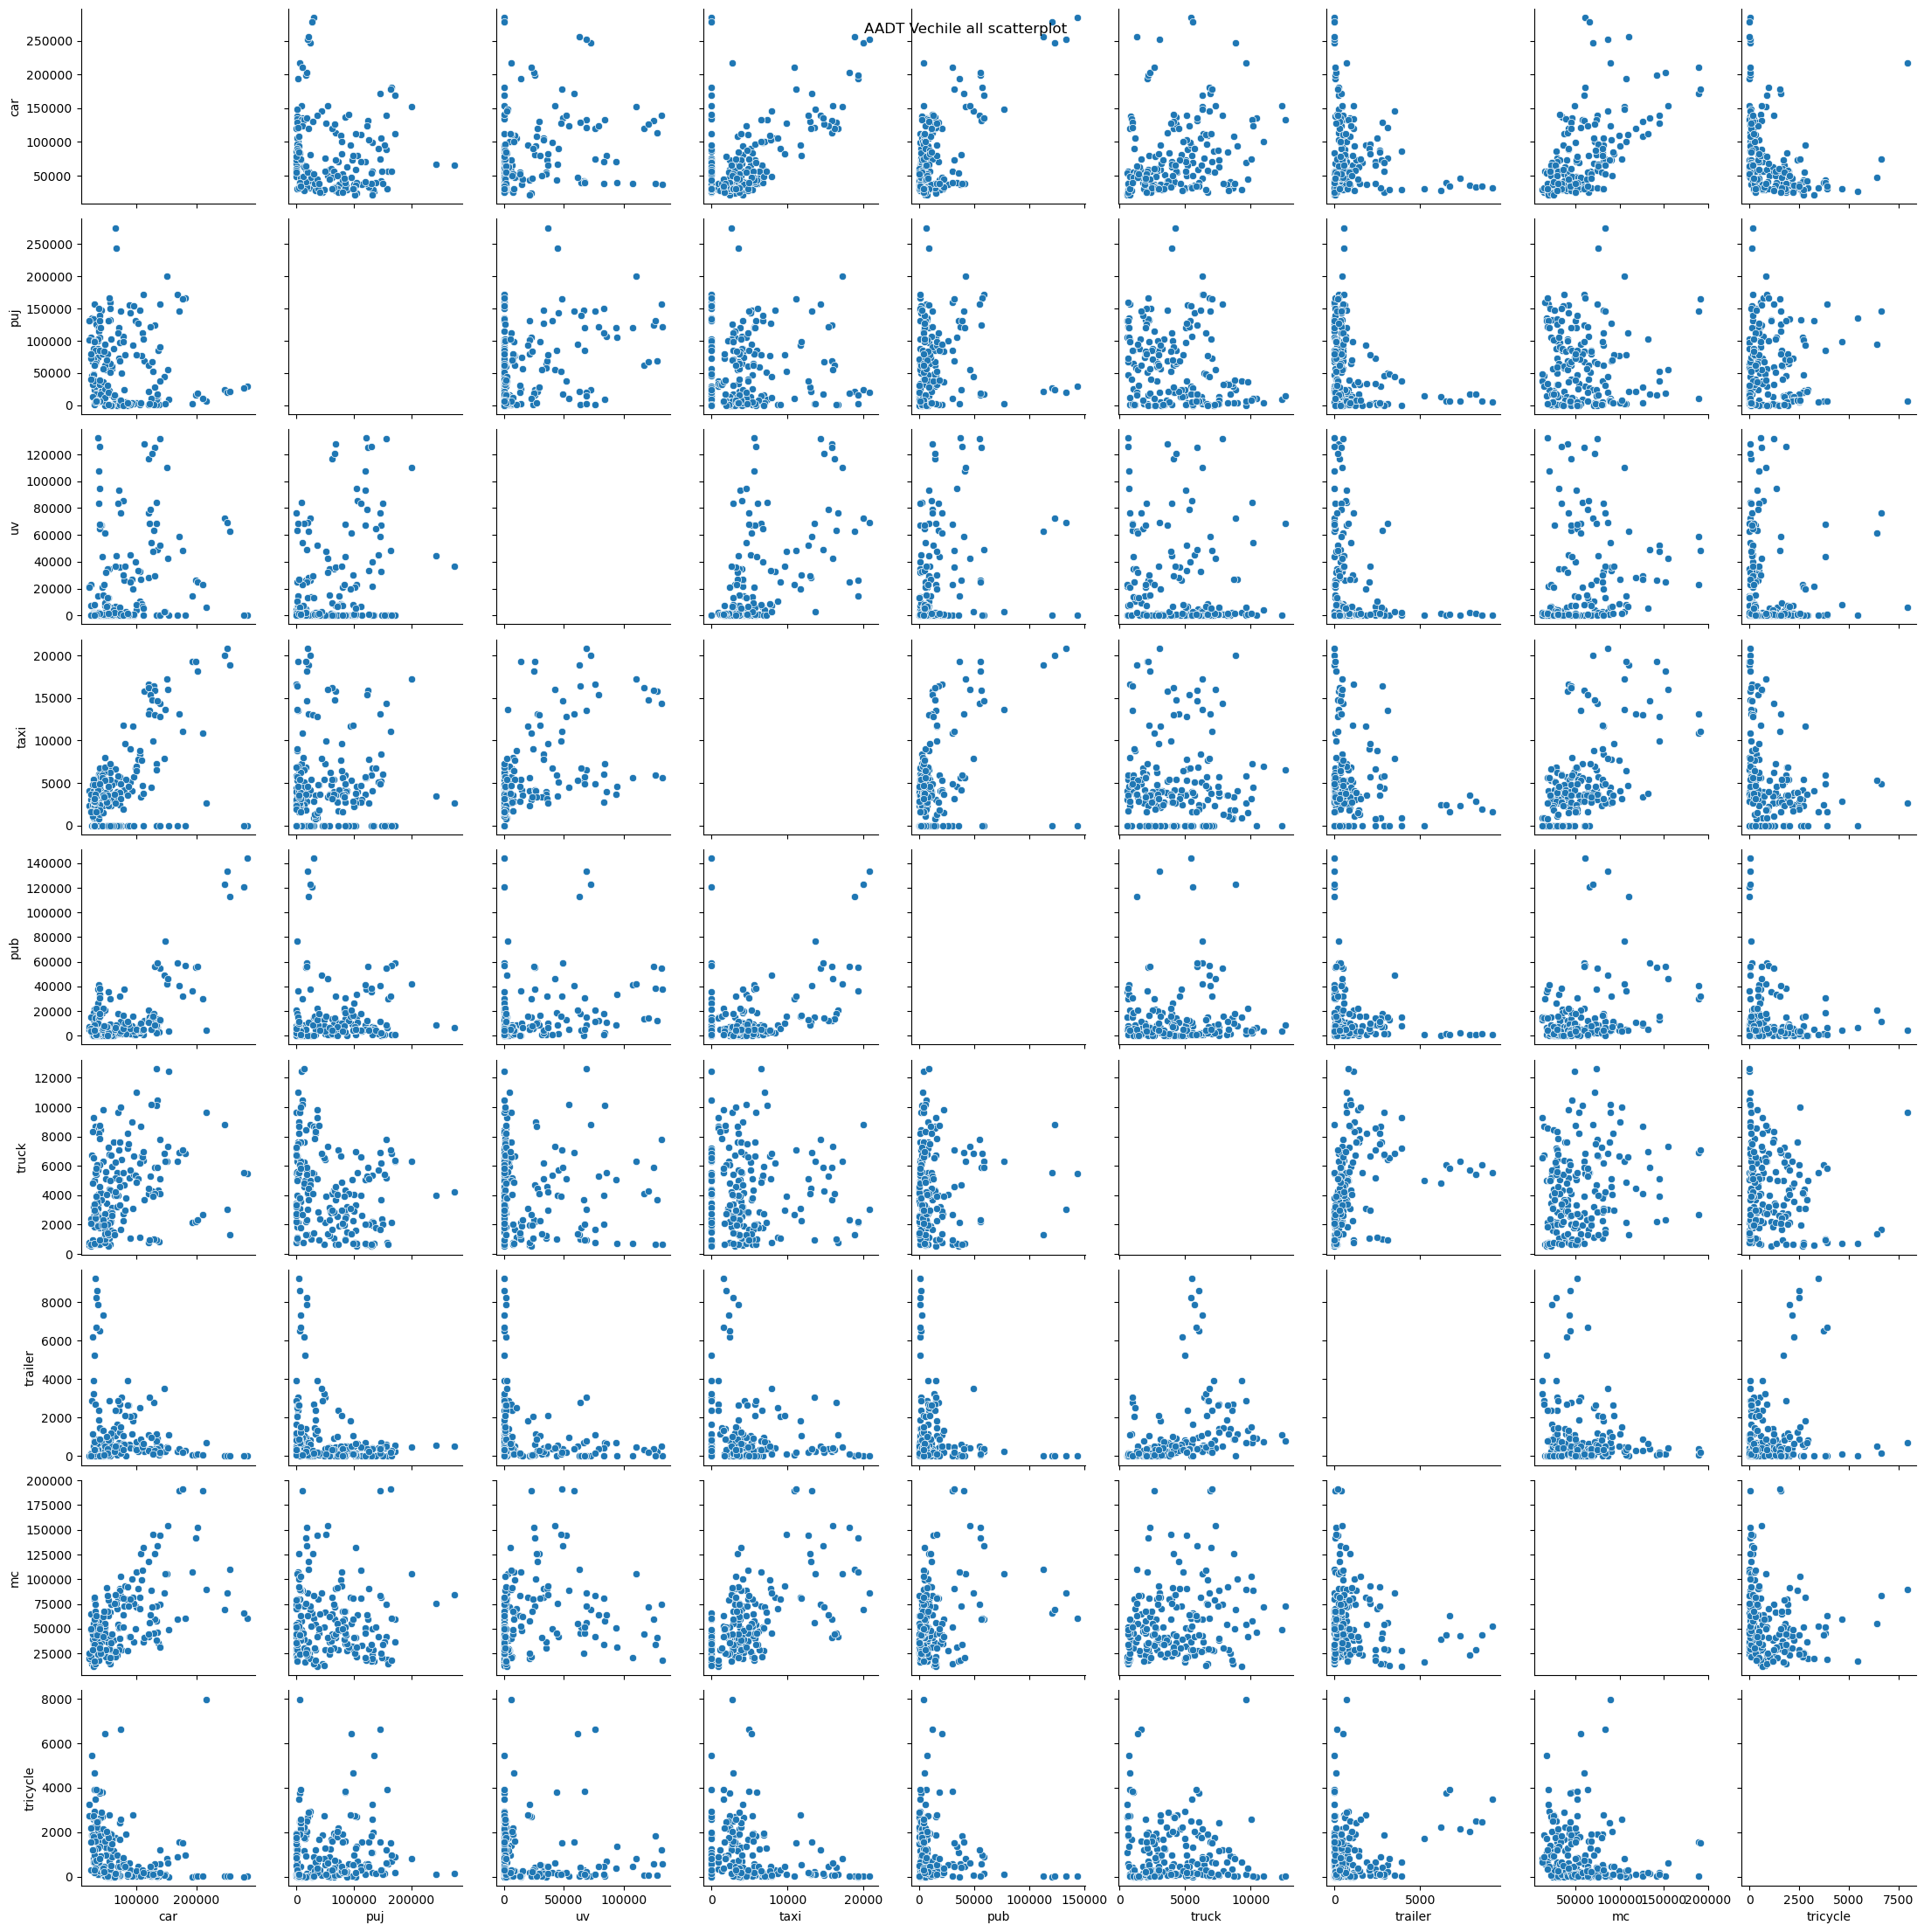

In [11]:
sns.pairplot(AADT[['year','car','puj','uv','taxi','pub','truck','trailer','mc','tricycle']], diag_kind='scatter')
plt.suptitle('AADT Vechile all scatterplot')
plt.savefig('AADT Vechile all scatterplot.png', dpi=300, bbox_inches='tight')
plt.show()

In [12]:
import datetime
vehicle_cols = ['car', 'puj', 'uv', 'taxi', 'pub', 'truck', 'trailer', 'mc', 'tricycle', 'total']
AADT_ML = AADT.copy()
AADT_ML['year_int'] = AADT_ML['year'].dt.strftime('%Y').astype('int')
AADT_ML = AADT_ML[AADT_ML['year_int'] > 2016]
def skew_check(dataset,val):
    print("Skewness Check:")
    for col in val:
        skew = dataset[col].skew()
        print(f"{col:10s}: {skew:6.2f} {'TRANSFORM' if abs(skew) > 1 else 'OK'}")

skew_check(AADT_ML, vehicle_cols)

Skewness Check:
car       :   1.56 TRANSFORM
puj       :   1.16 TRANSFORM
uv        :   1.51 TRANSFORM
taxi      :   1.52 TRANSFORM
pub       :   3.36 TRANSFORM
truck     :   0.58 OK
trailer   :   3.05 TRANSFORM
mc        :   1.30 TRANSFORM
tricycle  :   2.17 TRANSFORM
total     :   1.33 TRANSFORM


In [13]:
AADT_ML['car_log'] = np.log(AADT['car'])
AADT_ML['puj_sqrt'] = np.sqrt(AADT['puj'])
AADT_ML['uv_log1p'] = np.log(AADT['uv'])
AADT_ML['taxi_sqrt'] = np.sqrt(AADT['taxi'])
AADT_ML['pub_log'] = np.log(AADT['pub'])
AADT_ML['trailer_log1p'] = np.log1p(AADT['trailer'])
AADT_ML['mc_sqrt'] = np.sqrt(AADT['mc'])
AADT_ML['tricycle_sqrt'] = np.sqrt(AADT['tricycle'])
AADT_ML['total_log'] = np.log(AADT['total'])
skew_check(AADT_ML, ['car_log', 'puj_sqrt', 'uv_log1p', 'taxi_sqrt', 'pub_log','truck', 'trailer_log1p','mc_sqrt', 'tricycle_sqrt', 'total_log'])

Skewness Check:
car_log   :   0.43 OK
puj_sqrt  :   0.16 OK
uv_log1p  :  -0.34 OK
taxi_sqrt :   0.97 OK
pub_log   :  -0.72 OK
truck     :   0.58 OK
trailer_log1p:  -0.87 OK
mc_sqrt   :   0.56 OK
tricycle_sqrt:   0.68 OK
total_log :   0.45 OK


C:\Users\Lance\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


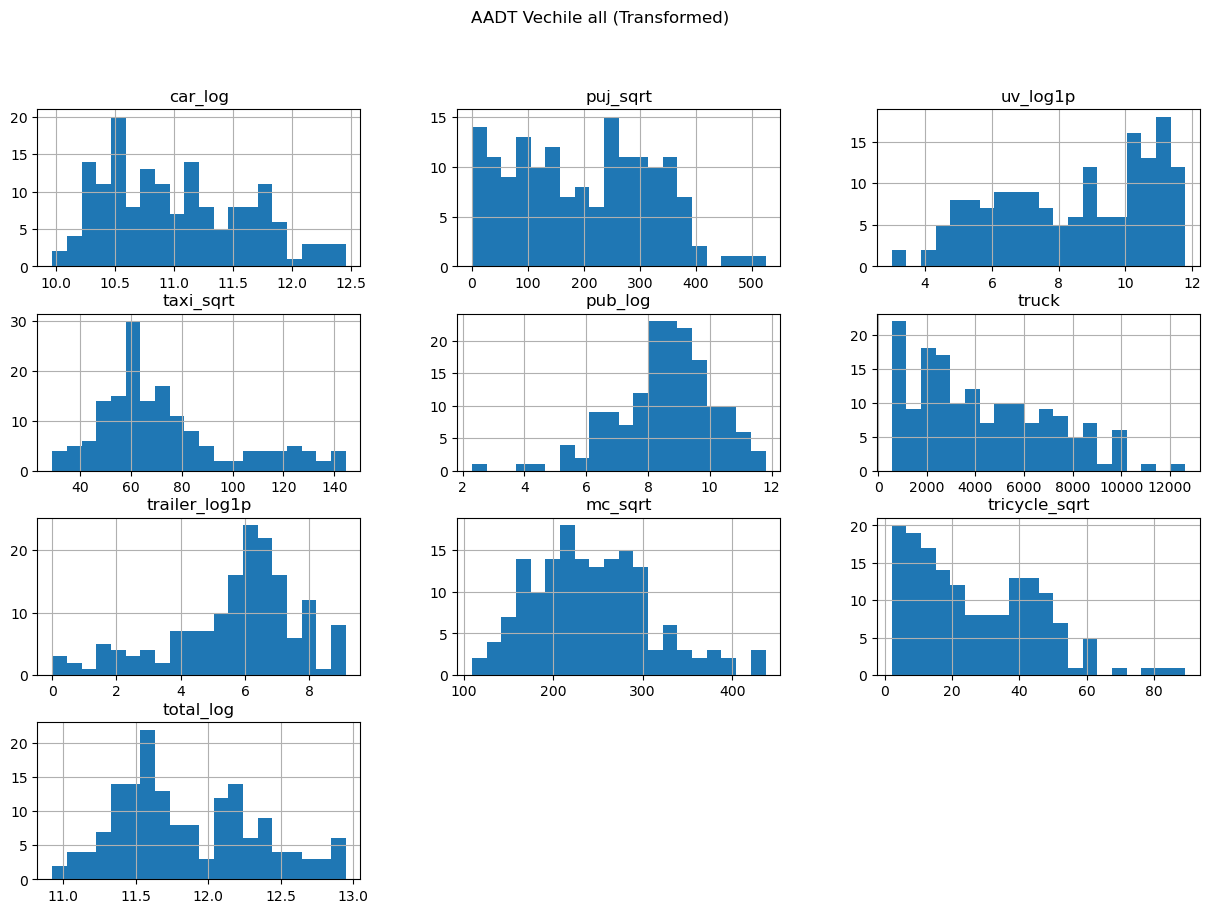

In [14]:
AADT_ML[['car_log', 'puj_sqrt', 'uv_log1p', 'taxi_sqrt', 'pub_log', 'truck', 'trailer_log1p','mc_sqrt', 'tricycle_sqrt', 'total_log']].hist(figsize=(15, 10), bins=20)
plt.suptitle('AADT Vechile all (Transformed)')
plt.show()

In [15]:
AADT_ML.describe()

,year,car,puj,uv,taxi,pub,truck,trailer,mc,tricycle,...,year_int,car_log,puj_sqrt,uv_log1p,taxi_sqrt,pub_log,trailer_log1p,mc_sqrt,tricycle_sqrt,total_log
count,160,160.000000,160.000000,160.0000,160.000000,160.000000,160.000000,160.000000,160.000000,160.000000,...,160.000000,160.000000,160.000000,160.000000,160.000000,160.000000,160.000000,160.000000,160.000000,160.000000
mean,2020-07-02 00:00:00,74160.418750,53985.500000,25424.6875,6107.312500,13489.187500,4317.731250,1028.781250,63443.125000,1087.706250,...,2020.500000,11.026156,197.392083,8.481238,73.487560,8.587575,5.657768,242.941540,27.152788,11.857065
min,2017-01-01 00:00:00,21366.000000,0.000000,20.0000,847.000000,10.000000,558.000000,0.000000,11938.000000,4.000000,...,2017.000000,9.969556,0.000000,2.995732,29.103264,2.302585,0.000000,109.261155,2.000000,10.922624
25%,2018-10-01 18:00:00,37709.750000,7270.000000,640.0000,3154.500000,2430.000000,2023.250000,107.000000,38907.750000,127.250000,...,2018.750000,10.537667,85.264295,6.461468,56.164284,7.795621,4.681603,197.247371,11.276725,11.515073
50%,2020-07-02 00:00:00,56307.000000,37185.000000,6655.0000,4203.500000,5940.000000,3854.500000,432.000000,54486.500000,481.500000,...,2020.500000,10.938574,192.833320,8.802737,64.834399,8.689463,6.070607,233.422475,21.942608,11.733607
75%,2022-04-02 06:00:00,99122.000000,85497.500000,37727.5000,6856.000000,14902.500000,6290.250000,1026.500000,81284.250000,1741.250000,...,2022.250000,11.504080,292.399555,10.537524,82.800956,9.609283,6.934841,285.103721,41.728280,12.181715
max,2024-01-01 00:00:00,255732.000000,275330.000000,132360.0000,20871.000000,133560.000000,12624.000000,9212.000000,191104.000000,7982.000000,...,2024.000000,12.451885,524.718972,11.793281,144.467990,11.802306,9.128371,437.154435,89.342039,12.947896
std,NaN,49964.854417,53104.983727,34722.6722,4671.944382,20867.444747,2767.577752,1722.391604,35411.602145,1326.261548,...,2.298482,0.597785,122.948536,2.336262,26.670898,1.548648,2.020796,66.710927,18.778614,0.475802


In [16]:
AADT.to_csv('AADT.csv', index=False)
AADT_ML.to_csv('AADT_ML.csv', index=False)